# Домашнее задание №4: изучаем работу деревьев и ансамблей деревьев

Классификация или регрессия на табличных данных это классические задачи, возникающие в бизнесе. Так выглядит задача в рисковых скорингах в банке, отчасти в рекомендательных системах в большинстве e-commerce площадок, в прогнозировании, купит или не купил клиент услугу по заданной цене в динамическом ценообразовании (в авиаперевозках, такси, ритейле и даже в финансовых сервисах).

Везде, где данные естественно записать в виде таблицы, почти всегда лучшее решение будет основано на градиентном бустинге над деревьями. Исключением здесь являются Computer Vision, Speech Recognition, Natural Language Processing и анализ графовых данных, поскольку там данные все-таки не табличные, и именно там себя в полной мере могут проявить нейросетевые архитектуры, но во всех остальных случаях ансамбли деревьев будут наиболее релевантным методом.

В этом задании 4 части:
1. В первой мы обучим модели на основе деревьев на реальном датасете, сравним различные модели и изучим, как модели ведут себя при изменении гиперпараметров
1. Во второй части вам предстоит пройти небольшой тест по теории, с чем вам помогут записи лекции и семинара.
1. В третьей части вы реализуете для задачи регрессии самостоятельно два ансамбля деревьев - случайный лес и градиентный бустинг.
1. Четвертая часть дополнительная, посвящена выбору разбиений в решающем дереве, и даст возможность добрать до 3 баллов дополнительно (ДЗ оценивается по 25-балльной шкале, далее оценка переводится в десятибалльную)

## Система оценивания домашнего задания

Максимально можно получить 25 баллов + 3 доп. балла за последнее задание в конце. Полученные баллы пересчитываются в десятибалльную оценку по формуле:

количество_баллов * 10 / максимум_баллов

**Дробные значения округляются вверх.** Например, доп. задание в конце, давая 3 / 25 = 1,2 балла, может повысить итоговую оценку на целых два балла по десятибалльной за счет округления.

---

**Пример:**

Если вы набрали 15 баллов из 25 в основной части и успешно решили дополнительное задание в конце еще на 3 балла, то:

10 * (15/25 + 3/25) = 6 + 1,2 = 7,2 => после округления вверх оценка 8 баллов из 10

## Часть 1: Анализ Регрессии и Сравнение Моделей

В этой части мы сравним работу "из коробки" регрессионного решающего дерева, случайного леса и различных реализаций градиентного бустинга (XGBoost, LightGBM и CatBoost) на данных California Housing dataset, в котором собраны цены на недвижимость в различных районах Калифорнии.

Далее мы перейдем к настройке параметров и изучим, как себя ведут кривые обучения (learning curves)


Библиотека CatBoost разработана в Яндексе и не стоит в Google Colab по умолчанию, установим ее:



In [6]:
!pip install catboost

Импортируем нужные нам библиотеки и выберем стиль отображения графиков:



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Настройка стиля графиков
sns.set(style="whitegrid")

Загрузим данные и подготовим обучающую и тестовую выборку:

In [8]:
# Загрузка данных
print("Загрузка данных California Housing...")
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Загрузка данных California Housing...
Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


Сравним модели, используя значения гиперпараметров, заданные по умолчанию:

In [28]:
# Сравнение моделей с параметрами по умолчанию
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

results = {}
print("\nОбучение моделей с параметрами по умолчанию...")
for name, model in models.items():

    ## ToDo: впишите код обучения модели на train и оценки rmse на test здесь
    ## Подсказка: RMSE можно посчитать как mean_squared_error из sklean в степени 0.5
    current_model = model
    current_model.fit(X_train, y_train)
    rmse = mean_squared_error(y_test, model.predict(X_test))
    results[name] = np.sqrt(rmse)
    print(f"{name} RMSE: {np.sqrt(rmse):.4f}")


Обучение моделей с параметрами по умолчанию...
LinearRegression RMSE: 0.7456
DecisionTree RMSE: 0.7037
RandomForest RMSE: 0.5053
XGBoost RMSE: 0.4718
LightGBM RMSE: 0.4635
CatBoost RMSE: 0.4460


Визуализируем результаты:

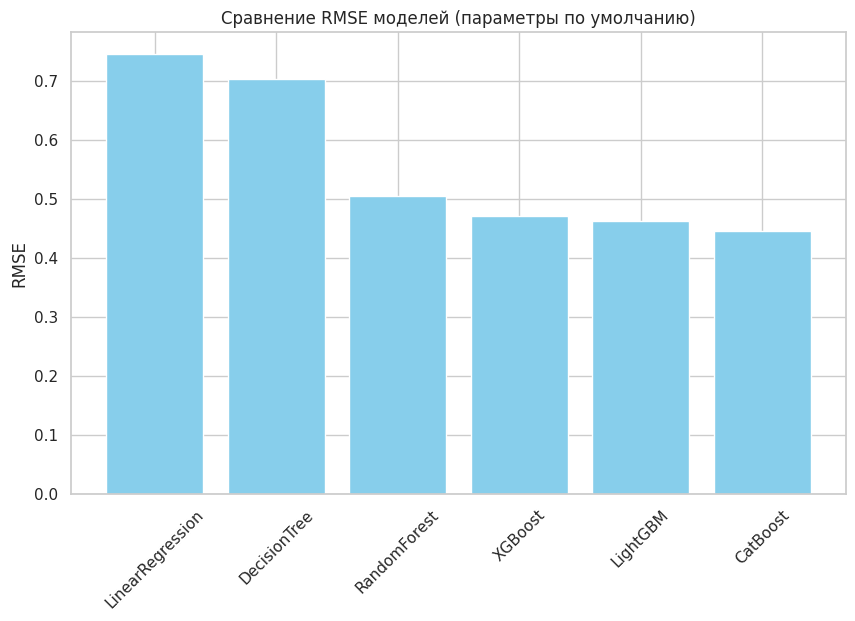

In [29]:
# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Сравнение RMSE моделей (параметры по умолчанию)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

Вопросы для проверки:

**1.1. Какая модель оказалась *лучшей* на тестовой выборке? [2 балла]**

* A) Linear Regression

* B) Decision Tree

* C) RandomForest

* D) XGBoost

* E) LightGBM

* F) CatBoost - **Ответ**

---

**1.2. Какая модель оказалась *худшей* на тестовой выборке? [2 балла]**

* A) Linear Regression - **Ответ**

* B) Decision Tree

* C) RandomForest

* D) XGBoost

* E) LightGBM

* F) CatBoost

Теперь подберем гиперпараметры для "деревянных" моделей. В дереве будем настраивать глубину, в случайном лесе количество деревьев и глубину, а в градиентом бустинге количество деревьев, глубину и learning rate. Для определенности будем использовать для градиентного бустинга библиотеку XGBoost (для остальных библиотек в рамках задания подбирать параметры не надо).

Выбрать набор параметров, которые нужно перебрать, это всегда творческая задача. Т.к. это учебное задание, вот значения, среди которых нужно будет найти лучший вариант:

Для глубины решающего дерева: 5, 10, 15, 20, None

Для глубины деревьев в Random Forest: 10, 20

Для количества деревьев в Random Forest: 50, 100

Для глубины деревьев в XGBoost: 3, 5

Для количества деревьев в XGBoost: 100, 200

Для learning rate: 0.01, 0.1

Во всех моделях используйте random_state=42, чтобы результаты были детерминированными.


Есть различные продвинутые методы и библиотеки для подбора гиперпараметров, но классика, которую можно сделать в любом случае, это перебрать несколько возможных значений по сетке. Сделать это поможет метод GridSearchCV из sklearn. Изучите документацию по GridSearch и напишите код его применения ниже. Параметр cv в GridSearch задайте равным 3.

In [11]:
# Подбор гиперпараметров (GridSearch)
print("Подбор гиперпараметров...")

# DecisionTree
print("Tuning DecisionTree...")
dt_params = {'max_depth': [5, 10, 15, 20, None]} ## ToDo: заполните список [] параметрами для перебора
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=3, scoring='neg_root_mean_squared_error')
dt_grid.fit(X_train, y_train)
print(f"Best DecisionTree Params: {dt_grid.best_params_}, Score: {-dt_grid.best_score_:.4f}")

# RandomForest
print("Tuning RandomForest...")

## ToDo: реализуйте перебор параметров RF
dt_params = {'max_depth': [10, 20], 'n_estimators': [50, 100]} ## ToDo: заполните список [] параметрами для перебора
dt_grid = GridSearchCV(RandomForestRegressor(random_state=42), dt_params, cv=3, scoring='neg_root_mean_squared_error')
dt_grid.fit(X_train, y_train)
print(f"Best RF Params: {dt_grid.best_params_}, Score: {-dt_grid.best_score_:.4f}")

# XGBoost
print("Tuning XGBoost...")

## ToDo: реализуйте перебор параметров XGBoost
dt_params = {'max_depth': [3, 5], 'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]} ## ToDo: заполните список [] параметрами для перебора
dt_grid = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42), dt_params, cv=3, scoring='neg_root_mean_squared_error')
dt_grid.fit(X_train, y_train)
print(f"Best XGB Params: {dt_grid.best_params_}, Score: {-dt_grid.best_score_:.4f}")

Подбор гиперпараметров...
Tuning DecisionTree...
Best DecisionTree Params: {'max_depth': 10}, Score: 0.6642
Tuning RandomForest...
Best RF Params: {'max_depth': 20, 'n_estimators': 100}, Score: 0.5163
Tuning XGBoost...
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}, Score: 0.4734


Вопросы для проверки:

**1.3. Оптимальное значение глубины дерева: [1 балл]**

* A) 5

* B) 10 - **Ответ**

* C) 15

* D) None (без ограничения)

---

**1.4. Оптимальное значение параметров в Random Forest: [1 балл]**

* A) 50, 10

* B) 50, 20

* C) 100, 10

* D) 100, 20 - - **Ответ**

---

**1.5 Оптимальное значение параметров в XGBoost: [1 балл]**

* A) 0.1, 5, 100

* B) 0.1, 5, 200 - - **Ответ**

* C) 0.01, 3, 100

* D) 0.01, 3, 200

## Визуализация переобучения (Overfitting)

А теперь посмотрим, переобучаются ли Random Forest и XGBoost с ростом количества деревьев и с ростом глубины деревьев.

Ниже приведен код для learning curve Random Forest в зависимости от количества деревьев, нужно дописать отображение на том же графике XGBoost и построить такие же графики в зависимости от глубины деревьев.

Для определенности, варьируя количество деревьев берите максимальную глубину по умолчанию, а варьируя глубину - количество деревьев по умолчанию. Переписывать код построения графика или перебора параметров для Random Forest **МОЖНО**

Значения параметров, которые нужно перебрать:

"n_estimators": [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000],

"max_depth": [3, 5, 10, 20, 30]

**Важно:** у автора задания код перебора параметров выполнялся в Collab примерно 10 минут, и это уже готовый правильный код, без учета отладки. Оставьте на это задание побольше времени

In [12]:
# Визуализация переобучения (Overfitting)

## ToDo: ниже приведен код для learning curve Random Forest в зависимости от
## количества деревьев, нужно дописать отображение на том же графике XGBoost +
## построить такие же графики в зависимости от глубины деревьев.
params_list = {"n_estimators": [1, 2, 5, 10, 20, 50, 100, 500, 1000],
               "max_depth": [3, 5, 10, 20, 30]}

print("=" * 60)
print("\nГенерация графика переобучения для Random Forest и XGB по кол-ву деревьев")
print("=" * 60)

train_errors = {
    "RF": [],
    "XGB": []
    }
test_errors = {
    "RF": [],
    "XGB": []
    }
i = 0
for param in params_list["n_estimators"]:
    i +=1
    print(f"-------- n_estimators = {param}. Шаг {i}/{len(params_list["n_estimators"])} -----------")

    print(f"Обучение rf...")
    rf = RandomForestRegressor(random_state=42, max_depth=max(params_list['max_depth']),  **{"n_estimators": param})
    rf.fit(X_train, y_train)
    print(f"Обучение XGB...")
    gbdt = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, max_depth=max(params_list['max_depth']), **{"n_estimators": param})
    gbdt.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    train_errors['RF'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_errors['RF'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

    y_train_pred = gbdt.predict(X_train)
    y_test_pred = gbdt.predict(X_test)

    train_errors['XGB'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_errors['XGB'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))




Генерация графика переобучения для Random Forest и XGB по кол-ву деревьев
-------- n_estimators = 1. Шаг 1/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 2. Шаг 2/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 5. Шаг 3/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 10. Шаг 4/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 20. Шаг 5/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 50. Шаг 6/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 100. Шаг 7/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 500. Шаг 8/9 -----------
Обучение rf...
Обучение XGB...
-------- n_estimators = 1000. Шаг 9/9 -----------
Обучение rf...
Обучение XGB...


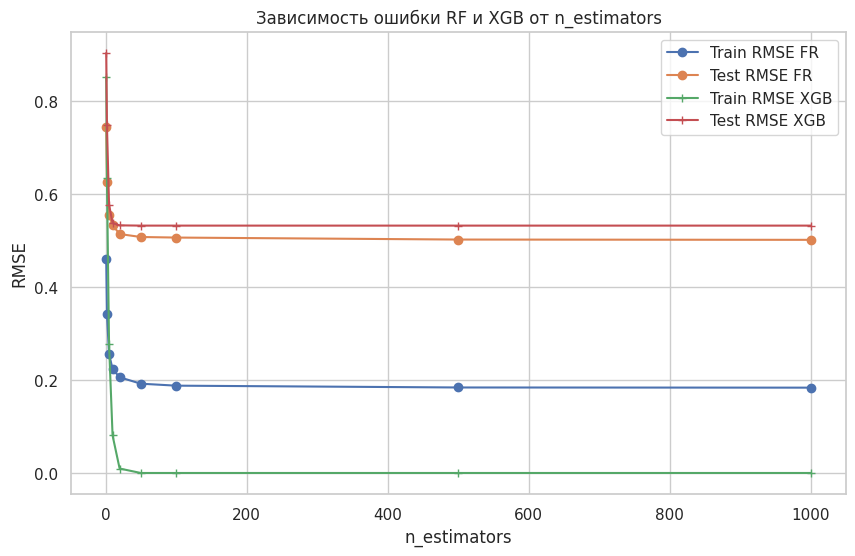

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(params_list["n_estimators"], train_errors['RF'], label='Train RMSE FR', marker='o')
plt.plot(params_list["n_estimators"], test_errors['RF'], label='Test RMSE FR', marker='o')
plt.plot(params_list["n_estimators"], train_errors['XGB'], label='Train RMSE XGB', marker='+')
plt.plot(params_list["n_estimators"], test_errors['XGB'], label='Test RMSE XGB', marker='+')
plt.title("Зависимость ошибки RF и XGB от " + "n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
print("=" * 60)
print("Генерация графика переобучения для Random Forest и XGB по глубине деревьев")
print("=" * 60)

train_errors = {
    "RF": [],
    "XGB": []
    }
test_errors = {
    "RF": [],
    "XGB": []
    }
i = 0
for param in params_list["max_depth"]:
    i +=1
    print(f"-------- max_depth = {param}. Шаг {i}/{len(params_list["max_depth"])} -----------")

    print(f"Обучение rf...")
    rf = RandomForestRegressor(random_state=42, n_estimators=max(params_list['n_estimators']),  **{"max_depth": param})
    rf.fit(X_train, y_train)
    print(f"Обучение XGB...")
    gbdt = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=max(params_list['n_estimators']),  **{"max_depth": param})
    gbdt.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    train_errors['RF'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_errors['RF'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

    y_train_pred = gbdt.predict(X_train)
    y_test_pred = gbdt.predict(X_test)

    train_errors['XGB'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_errors['XGB'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))


Генерация графика переобучения для Random Forest и XGB по глубине деревьев
-------- max_depth = 3. Шаг 1/5 -----------
Обучение rf...
Обучение XGB...
-------- max_depth = 5. Шаг 2/5 -----------
Обучение rf...
Обучение XGB...
-------- max_depth = 10. Шаг 3/5 -----------
Обучение rf...
Обучение XGB...
-------- max_depth = 20. Шаг 4/5 -----------
Обучение rf...
Обучение XGB...
-------- max_depth = 30. Шаг 5/5 -----------
Обучение rf...
Обучение XGB...


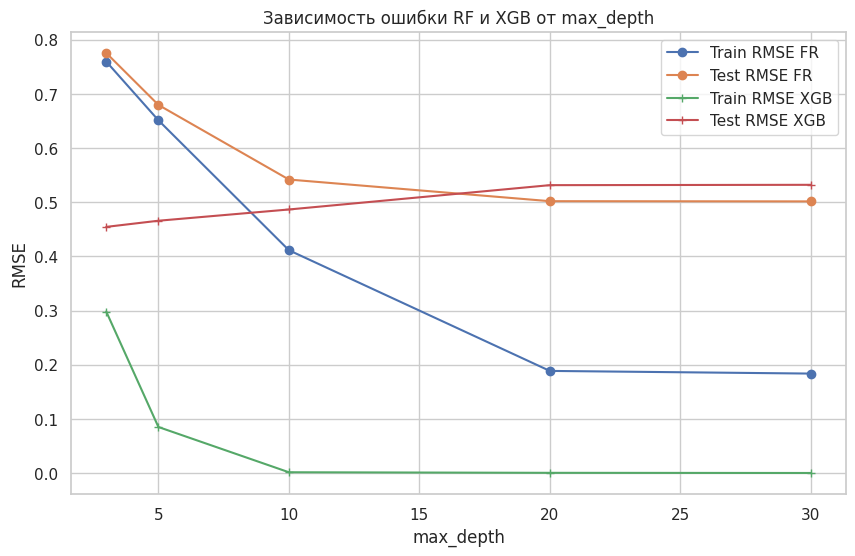

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(params_list["max_depth"], train_errors['RF'], label='Train RMSE FR', marker='o')
plt.plot(params_list["max_depth"], test_errors['RF'], label='Test RMSE FR', marker='o')
plt.plot(params_list["max_depth"], train_errors['XGB'], label='Train RMSE XGB', marker='+')
plt.plot(params_list["max_depth"], test_errors['XGB'], label='Test RMSE XGB', marker='+')
plt.title("Зависимость ошибки RF и XGB от " + "max_depth")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Вопросы для проверки:

**1.6. Росла ли в экспрерименте ошибка Random Forest на тестовой выборке с ростом количества деревьев: [1 балл]**

* A) Да

* B) Нет - Ответ

* C) Нельзя сказать однозначно


---

**1.7. Росла ли в экспрерименте ошибка Random Forest на тестовой выборке с ростом глубины деревьев: [1 балл]**

* A) Да

* B) Нет - Ответ

* C) Нельзя сказать однозначно

---
**1.8. Росла ли в экспрерименте ошибка XGBoost на тестовой выборке с ростом количества деревьев: [1 балл]**

* A) Да

* B) Нет - Ответ

* C) Нельзя сказать однозначно

---

**1.9 Росла ли в экспрерименте ошибка XGBoost на тестовой выборке с ростом глубины деревьев: [1 балл]**

* A) Да - - Ответ

* B) Нет

* C) Нельзя сказать однозначно

---

**1.10 Какое утверждение про переобучение моделей верно: [1 балл]**

*Важно:* под переобучением в данном вопросе следует понимать не просто существенное различие ошибки на train и test, а ситуацию, когда с ростом параметра (например, количества деревьев), ошибка на train продолжает уменьшаться, а ошибка на test начинает увеличиваться.

* A) RandomForestRegressor в нашем эксперименте переобучался с ростом количества деревьев и их глубины, XGBoost - нет

* B) XGBoost в нашем эксперименте переобучался с ростом количества деревьев и их глубины, RandomForestRegressor - нет

* C) XGBoost в нашем эксперименте переобучался с ростом глубины деревьев, но на данных параметрах не переобучился с ростом количества деревьев. RandomForestRegressor не переобучился в обоих случаях. - **Ответ**

* D) XGBoost и RandomForestRegressor оба не переобучались в нашем эксперименте ни с ростом количества деревьев, ни с ростом их глубины.


## Часть 2: Теоретические вопросы

Выберите правильный ответ для следующих вопросов:

**2.1: Глубина деревьев в ансамбле [1 балл]**

Надо ли ограничивать глубину деревьев в Random Forest и в Gradient Boosting?

*   A) В Gradient Boosting не обязательно, в Random Forest надо
*   B) В Gradient Boosting надо, в Random Forest не обязательно - **Ответ**
*   C) И в Gradient Boosting, и в Random Forest надо
*   D) Глубина деревьев жестко зафиксирована и в Gradient Boosting, и в Random Forest

---

**2.2: Разнообразие в Random Forest [1 балл]**

Какие механизмы использует Random Forest для обеспечения разнообразия (diversity) базовых моделей?

*   A) Только бутстрэп (Bagging) обучающей выборки.
*   B) Только случайный выбор подмножества признаков при каждом сплите.
*   C) И бутстрэп (Bagging) обучающей выборки, и случайный выбор подмножества признаков при каждом сплите. - **Ответ**
*   D) Последовательное обучение на ошибках предыдущих деревьев.

---

**2.3: Параллелизм vs Последовательность [1 балл]**

В чем основное архитектурное различие между Random Forest и Gradient Boosting?

*   A) Деревья в Random Forest строятся независимо (параллельно), а в Gradient Boosting — последовательно. - **Ответ**
*   B) Деревья в Random Forest строятся последовательно, а в Gradient Boosting — параллельно.
*   C) Оба алгоритма строят все деревья параллельно.
*   D) Random Forest использует линейные модели, а Gradient Boosting — деревья.

---

**2.4: Скорость обучения (Learning Rate) в бустинге [1 балл]**

Какова роль гиперпараметра `learning_rate` (или $\eta$) в градиентном бустинге?

*   A) Он определяет максимальную глубину деревьев.
*   B) Он масштабирует вклад каждого нового дерева в общую модель, предотвращая переобучение. - **Ответ**
*   C) Он выбирает количество признаков для каждого дерева.
*   D) Он определяет долю данных, используемых для валидации.

---

**2.5: Компромисс смещения и дисперсии (Bias-Variance Tradeoff) [1 балл]**

Как обычно изменяются компоненты ошибки ($Bias^2$ и $Variance$) при переходе от одиночного решающего дерева к случайному лесу (Random Forest)?

*   A) $Bias^2$ значительно уменьшается, $Variance$ остается неизменной.
*   B) $Bias^2$ увеличивается, $Variance$ уменьшается.
*   C) $Bias^2$ остается примерно на том же уровне (или незначительно увеличивается), а $Variance$ значительно уменьшается. - **Ответ**
*   D) И $Bias^2$, и $Variance$ значительно увеличиваются.

---

**2.6: Вероятность ошибки в листе дерева [1 балл]**

Решающее дерево, построенное для классификации на $K$ классов, отвечает в своем листе классом $k = arg\max\limits_k p_k$, где $p_k$ - доля объектов класса $k$ в листе. Считая, что для каждого $k$ эта доля очень точно оценивает реальную вероятность того, что объект, попавший в этот лист дерева имеет класс $k$ (т.е., считая $p_k$ не просто долей, но и настоящей вероятностью класса $k$), выберите вероятность, с которой дерево ошибается при классификации. Считаем, что $\max\limits_k p_k = p_{max}$.

*   A) $p_{max}$
*   B) $p_{max}(1 - p_{max})$
*   C) $1 - p_{max}$ - **Ответ**
*   D) $\sum\limits_{k=1}^{K}p_{k}(1 - p_{k})$

---

**2.7: Вероятностный смысл критерия Gini [1 балл]**

В ситуации из прошлого вопроса представьте теперь, что решающее дерево отвечает в листе случайным классом, причем вероятность **ответить** $k$ равна $p_k$, где $p_k$ - все также доля объектов класса $k$ в листе. По-прежнему считая $p_k$ не просто долей, но и настоящей вероятностью класса $k$, выберите вероятность, с которой дерево ошибается при классификации.

*   A) $\sum\limits_{k=1}^{K}(1 - p_{k})$
*   B) $p_{max}(1 - p_{max})$
*   C) $1 - p_{max}$
*   D) $\sum\limits_{k=1}^{K}p_{k}(1 - p_{k})$ - Ответ



## Часть 3: Реализация алгоритмов

В этой части вам предстоит реализовать упрощенные версии Random Forest и Gradient Boosting с нуля, используя `DecisionTreeRegressor` из `sklearn` в качестве базовой модели.

### Задание:
1. Реализуйте класс `MyRandomForest`, поддерживающий бутстрэп-выборки и агрегацию предсказаний.
2. Реализуйте класс `MyGradientBoosting`, поддерживающий обучение на остатках (градиентный спуск в пространстве функций).
3. Проверьте работу ваших реализаций на данных California Housing и сравните RMSE с библиотечными версиями.

In [25]:
class MyRandomForest:
    def __init__(self, n_estimators=10, max_depth=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        np.random.seed(self.random_state)
        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # TODO: Реализовать бутстрэп (выборка с возвращением)
            indices = np.random.choice(np.arange(n_samples), n_samples, replace=True)
            X_sample = X.iloc[indices]
            y_sample = y.iloc[indices]
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state + i, max_features='sqrt')
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        # TODO: Получить предсказания от всех деревьев и усреднить их
        predictions = []
        for tree in self.trees:
          predictions.append(tree.predict(X))
        return np.mean(predictions, axis=0)


In [21]:
class MyGradientBoosting:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None

    def fit(self, X, y):
        self.trees = []
        self.initial_prediction = np.mean(y)
        y_pred = np.full(y.shape, self.initial_prediction)
        for i in range(self.n_estimators):
            # TODO: Рассчитать остатки (residuals)
            residuals = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state + i, max_features='sqrt')
            tree.fit(X, residuals)
            self.trees.append(tree)
            # TODO: Обновить текущие предсказания с учетом learning_rate
            update = tree.predict(X)
            y_pred += self.learning_rate * update

        return self

    def predict(self, X):
        # TODO: Суммировать начальное предсказание и вклад всех деревьев (умноженный на learning_rate)
        y_pred = self.initial_prediction
        for tree in self.trees:
          y_pred += self.learning_rate * tree.predict(X)
        return y_pred


Проверка для кастомной реализации алгоритмов:



In [30]:
print("Проверка кастомных реализаций...")

# Проверка MyRandomForest
print("Training MyRandomForest...")
my_rf = MyRandomForest(n_estimators=100, max_depth=20, random_state=42)
my_rf.fit(X_train, y_train)
my_rf_pred = my_rf.predict(X_test)
my_rf_rmse = np.sqrt(mean_squared_error(y_test, my_rf_pred))
print(f"MyRandomForest RMSE: {my_rf_rmse:.4f}")

# Проверка MyGradientBoosting
print("Training MyGradientBoosting...")
my_gb = MyGradientBoosting(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
my_gb.fit(X_train, y_train)
my_gb_pred = my_gb.predict(X_test)
my_gb_rmse = np.sqrt(mean_squared_error(y_test, my_gb_pred))
print(f"MyGradientBoosting RMSE: {my_gb_rmse:.4f}")

# Сравнение с результатами из первой части
print("\n--- Сравнение с библиотечными реализациями ---")
print(f"Sklearn RandomForest RMSE: {results['RandomForest']:.4f}")
print(f"Sklearn XGBoost RMSE: {results['XGBoost']:.4f}")

Проверка кастомных реализаций...
Training MyRandomForest...
MyRandomForest RMSE: 0.4980
Training MyGradientBoosting...
MyGradientBoosting RMSE: 0.4821

--- Сравнение с библиотечными реализациями ---
Sklearn RandomForest RMSE: 0.5053
Sklearn XGBoost RMSE: 0.4718


**Важно: постарайтесь добиться минимального различия между качеством вашего решения и качеством библиотечной реализации на выбранном датасете**

Вопросы для проверки:

**3.1. В каком знаке после запятой ошибка на тестовой выборке у вашей реализации начинает отличаться от библиотечной? [2 балла]**

* A) в первом знаке после запятой - Ответ(но у моих моделей меньше ошибка)

* B) во втором знаке после запятой

* C) в третьем знаке после запятой

* D) ни в каком знаке, ошибки полностью совпали



**3.2. Какой из реализованных вами (не библиотечных) алгоритмов отработал лучше на тестовой выборке: [2 балла]**

* A) Random Forest

* B) Gradient Boosting - Ответ

* C) Ошибка получилась одинаковой




**3.3. Сколько процентов от наибольшей из двух ошибок составила разница между ошибкой случайного леса и градиентного бустинга на тестовой выборке? [2 балла]**

* A) от 4% до 9%

* B) от 2% до 3.99% - Ответ

* C) от 0.3% до 1.99%

* D) строго больше 10%



# Часть 4: опциональная (на дополнительные баллы): выбор разбиений в дереве решений

Дерево решений можно воспринимать как набор правил вида «если‑то», очень похожих на то, как в бизнесе принимают решения по порогам:
*если скоринг > 650 => одобряем кредит*, *если доставка > 7 дней => риск возврата*, *если активность < X => возможно, пользователь уходит*.

Разберём, как на самом деле происходит **сплит по непрерывной фиче** (выбор порога) внутри дерева.

Мы не будем останавливаться на всех реализациях обучения деревьев, но полезно знать, что в продакшене встречаются разные семейства:

* ID3
* CART (с модификациями используется в `sklearn`)
* C4.5 (J48)
* C5.0
* CN2
* CHAID
* Symmetric/Oblivious Trees (CatBoost)

Здесь сфокусируемся именно на механике выбора порога.

Для наглядности напишем пару вспомогательных функций.

In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from operator import itemgetter

In [ ]:
VERY_BIG = 1e90

In [ ]:
def split_criterion(x, x_treshold, target, type = 'entropy'):
  assert len(x) == len(target)
  if type not in ['MSE', 'entropy', 'gini_impurity']:
    return 'incorrect criterion type'
  x = pd.Series(x)
  target = pd.Series(target, index = x.index)
  target_left, target_right = target[x < x_treshold], target[x >= x_treshold]
  if (not len(target_left)) or (not len(target_left)):
    return VERY_BIG
  if type == 'MSE':
    x_left, x_right = x[x < x_treshold], x[x >= x_treshold]
    prediction_left, prediction_right = np.mean(x_left), np.mean(x_right)
    mse_left, mse_right = sum((target_left - prediction_left) ** 2), sum((target_right - prediction_right) ** 2)
    return (len(target_left) * mse_left + len(target_right) * mse_right) / len(target)

  p_left, p_right = np.mean(target_left), np.mean(target_right)
  if type == 'gini_impurity':
    return 1 - (p_left ** 2 + p_right ** 2)
  if type == 'entropy':
    if (not p_left) or (not p_right):
      return VERY_BIG
    else:
      return -p_left * np.log2(p_left) -p_right * np.log2(p_right)

Посмотрим на выбор сплита перебором порога в задаче классификации *aka как выбрать «правильный» порог, чтобы лучше разделить клиентов на два сегмента?*

In [ ]:
feature = [5, 6, 7, 8, 9, 10, 2]
target = [1, 0, 1, 0, 1, 1, 1]
t = []
for feature_treshold in feature[0:-1]:
  t.append([feature_treshold, split_criterion(feature, feature_treshold, target, type = 'entropy')])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Порог', 'Значение критерия']))

Убедимся, что пороги 5 и 10 одинаково хорошо разделяют данные: посчитаем долю единиц в поддеревьях.

In [ ]:
feature = pd.Series(feature)
target = pd.Series(target, index = feature.index)
print(np.mean(target[feature < 5]), np.mean(target[feature >= 5]))
print(np.mean(target[feature < 10]), np.mean(target[feature >= 10]))

Теперь перейдём к стратегиям выбора порогов: как алгоритм решает, **где поставить границу**.

In [ ]:
from sklearn.datasets import make_classification

In [ ]:
random_state = 88
x, y = make_classification(5_000, 10, random_state = random_state)

Реализуем самую простую стратегию выбора первого узла дерева

In [ ]:
%%time
best_splits = []
for idx_feature, feature in enumerate(x.T):
  t = []
  for feature_treshold in feature[0:-1]:
    t.append([feature_treshold, split_criterion(feature, feature_treshold, y, type = 'entropy')])
  best_split_index = np.nanargmin(np.array(t)[:, 1], axis = 0)
  best_splits.append([idx_feature, t[best_split_index][0], t[best_split_index][1]])
best_splits = sorted(best_splits, reverse = True, key = itemgetter(1))
print(tabulate(best_splits, headers = ['Feature', 'Порог', 'Значение критерия']))
print('the winner is')
best_of_best_split = np.nanargmin(np.array(best_splits)[:,2], axis = 0)
print(tabulate([best_splits[best_of_best_split]], headers = ['Feature', 'Порог', 'Значение критерия']))

Это считалось долго, и в реальных данных так же бывает: мы перебрали **все фичи и все пороги**: всего около 5 000 кандидатов на сплит.

В продакшене при тысячах фичей и миллионах строк такой перебор становится узким местом по времени/ресурсам.

## Задание
Как посчитать радикально быстрее?

Один из практичных подходов — **биннинг** (строим гистограммы и считаем только по бинам). Однако дерево будет уже другим, иногда качество немного падает, зато обучение ускоряется на порядки.

**Реализуйте данный подход на собственном коде ниже.**
Подсказка: используйте `pd.qcut` для разбиения на бины с примерно равным числом объектов.

In [ ]:
%%time
best_splits = []
for idx_feature, feature in enumerate(x.T):
  t = []
  _, bins = # INSERT YOUR CODE
  for feature_treshold in bins:
    # INSERT YOUR CODE
  best_split_index = # INSERT YOUR CODE
  best_splits.append(# INSERT YOUR CODE)
best_splits = sorted(best_splits, reverse = True, key = itemgetter(1))
print(tabulate(best_splits, headers = ['Feature', 'Порог', 'Значение критерия']))
print('the winner is')
best_of_best_split = np.nanargmin(np.array(best_splits)[:,2], axis = 0)
print(tabulate([best_splits[best_of_best_split]], headers = ['Feature', 'Порог', 'Значение критерия']))

## 4.1 Вопрос для теста [3 доп. балла]:
При числе бинов в гистограмме равной 128 какая фича окажется в корне дерева?



1.   feature_0
2.   feature_1
3.   feature_2
4.   feature_3
5.   feature_4
6.   feature_5
7.   feature_6
8.   feature_7
9.   feature_8
10.  feature_9



Стратегии выбора порогов бывают очень разные. Например, в CatBoost для этого есть отдельная логика:

https://catboost.ai/docs/en/concepts/quantization